# Health Data Trend Report

### Tools Used:
Python  
Pandas  
Matplotlib  
Seaborn  
Streamlit  

### Objective:
To analyze healthcare data and identify trends in patient demographics, medical conditions, admission types, and billing patterns.

## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2 — Load Dataset

In [3]:
df = pd.read_excel("healthcare_dataset.xlsx")
df.head()

,ID,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,1,aAroN ADaMS,38,Female,O-,Cancer,2021-03-10,Norma Li,Hart LLC,UnitedHealthcare,26052.106404,363,Elective,2021-03-29,Lipitor,Inconclusive
1,2,aAROn aguIRRe,36,Male,A-,Diabetes,2023-02-26,Katrina Luna,Murray-Shelton,UnitedHealthcare,27087.560553,300,Emergency,2023-03-13,Aspirin,Inconclusive
2,3,AArOn AnderSoN,50,Female,A+,Asthma,2020-12-18,Kenneth Jennings,Tanner-Cox,Cigna,39804.658624,196,Urgent,2021-01-15,Aspirin,Inconclusive
3,4,aaRON AndeRSoN md,20,Female,A-,Hypertension,2021-03-28,Tammy Perez,Ritter LLC,UnitedHealthcare,16846.415799,249,Elective,2021-04-09,Paracetamol,Abnormal
4,5,AAron ArCHER,47,Female,B-,Cancer,2021-01-10,Cynthia Villanueva,"Montes Case and Mendez,",Medicare,10602.077185,108,Urgent,2021-01-17,Paracetamol,Inconclusive


## Step 3 — Check dataset size

In [4]:
df.shape

(55500, 16)

## Step 4 — Data Problem Statement

- Healthcare organizations generate large amounts of patient data including age, gender, medical conditions, admission type, and billing details.

- The objective of this project is to analyze healthcare data and identify trends in patient demographics, common medical conditions, hospital admission patterns, and billing amounts.

- By analyzing this data, we aim to understand patterns that can help in improving healthcare planning, resource allocation, and cost management.

- This project focuses on exploratory data analysis (EDA) to discover meaningful insights from healthcare records.

## Step 5 — Data Collection

- The dataset used in this project is a healthcare dataset containing 55,500 patient records with 16 attributes.

- The dataset includes important information such as:

• Patient demographics (Age, Gender, Blood Type)
• Medical condition of patient
• Admission type (Emergency, Urgent, Elective)
• Hospital and doctor details
• Billing amount and insurance provider
• Medication and test results
• Date of admission and discharge

- The dataset is stored in Excel format (.xlsx) and loaded into Python using pandas library.

## Step 6 — Data Cleaning

- Data cleaning is an important step before analysis to ensure the dataset is accurate and consistent.

- In this step we:

• checked for missing values

• checked for duplicate records

• standardized text formatting

• created age group categories for better analysis

### check missing values

In [5]:
df.isnull().sum()

ID                    0
Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

### check duplicate rows

In [6]:
df.duplicated().sum()

np.int64(534)

### Removing Duplicates

In [7]:
df = df.drop_duplicates()

### Rechecking for duplicates

In [8]:
df.duplicated().sum()

np.int64(0)

### Standardize text format


In [9]:
df["Name"] = df["Name"].str.title()
df["Medical Condition"] = df["Medical Condition"].str.title()
df["Doctor"] = df["Doctor"].str.title()
df["Hospital"] = df["Hospital"].str.title()
df["Insurance Provider"] = df["Insurance Provider"].str.title()
df["Medication"] = df["Medication"].str.title()

### Create Age Group column (important for trend)

In [10]:
def age_group(age):
    if age < 30:
        return "Young"
    elif age < 50:
        return "Adult"
    else:
        return "Senior"

df["Age Group"] = df["Age"].apply(age_group)

df.head()

,ID,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Age Group
0,1,Aaron Adams,38,Female,O-,Cancer,2021-03-10,Norma Li,Hart Llc,Unitedhealthcare,26052.106404,363,Elective,2021-03-29,Lipitor,Inconclusive,Adult
1,2,Aaron Aguirre,36,Male,A-,Diabetes,2023-02-26,Katrina Luna,Murray-Shelton,Unitedhealthcare,27087.560553,300,Emergency,2023-03-13,Aspirin,Inconclusive,Adult
2,3,Aaron Anderson,50,Female,A+,Asthma,2020-12-18,Kenneth Jennings,Tanner-Cox,Cigna,39804.658624,196,Urgent,2021-01-15,Aspirin,Inconclusive,Senior
3,4,Aaron Anderson Md,20,Female,A-,Hypertension,2021-03-28,Tammy Perez,Ritter Llc,Unitedhealthcare,16846.415799,249,Elective,2021-04-09,Paracetamol,Abnormal,Young
4,5,Aaron Archer,47,Female,B-,Cancer,2021-01-10,Cynthia Villanueva,"Montes Case And Mendez,",Medicare,10602.077185,108,Urgent,2021-01-17,Paracetamol,Inconclusive,Adult


## Step 7 — Statistical Summary

Statistical summary helps in understanding numerical characteristics of the dataset such as average age, billing amount distribution, and frequency of categorical variables.

We analyze:

• distribution of gender

• frequency of medical conditions

• age group distribution

• admission type distribution

• average billing amount


### Numerical summary

In [11]:
df.describe()

,ID,Age,Date of Admission,Billing Amount,Room Number,Discharge Date
count,54966.000000,54966.000000,54966,54966.000000,54966.000000,54966
mean,27472.105411,51.535185,2021-11-01 17:35:29.505512448,25544.306284,301.124404,2021-11-17 05:34:28.202161408
min,1.000000,13.000000,2019-05-08 00:00:00,-2008.492140,101.000000,2019-05-09 00:00:00
25%,13737.250000,35.000000,2020-07-28 00:00:00,13243.718641,202.000000,2020-08-13 00:00:00
50%,27470.500000,52.000000,2021-11-02 00:00:00,25542.749145,302.000000,2021-11-18 00:00:00
75%,41207.750000,68.000000,2023-02-03 00:00:00,37819.858159,401.000000,2023-02-19 00:00:00
max,54944.000000,89.000000,2024-05-07 00:00:00,52764.276736,500.000000,2024-06-06 00:00:00
std,15860.806535,19.605661,NaN,14208.409711,115.223143,NaN


### Gender distribution count

In [12]:
df["Gender"].value_counts()

Gender
Male      27496
Female    27470
Name: count, dtype: int64

### Medical condition frequency

In [13]:
df["Medical Condition"].value_counts()

Medical Condition
Arthritis       9218
Diabetes        9216
Hypertension    9151
Obesity         9146
Cancer          9140
Asthma          9095
Name: count, dtype: int64

### Age group frequency

In [14]:
df["Age Group"].value_counts()

Age Group
Senior    29211
Adult     16150
Young      9605
Name: count, dtype: int64

### Admission type frequency

In [15]:
df["Admission Type"].value_counts()

Admission Type
Elective     18473
Urgent       18391
Emergency    18102
Name: count, dtype: int64

### Average billing amount

In [16]:
df["Billing Amount"].mean()

np.float64(25544.30628438392)

### Average billing by medical condition

In [17]:
df.groupby("Medical Condition")["Billing Amount"].mean()

Medical Condition
Arthritis       25511.783246
Asthma          25633.461696
Cancer          25152.322947
Diabetes        25660.478635
Hypertension    25503.058720
Obesity         25804.361902
Name: Billing Amount, dtype: float64

## Step 8 — Visualization

Data visualization helps in understanding patterns and trends in healthcare data using graphical representation.

### 1. Gender Distribution

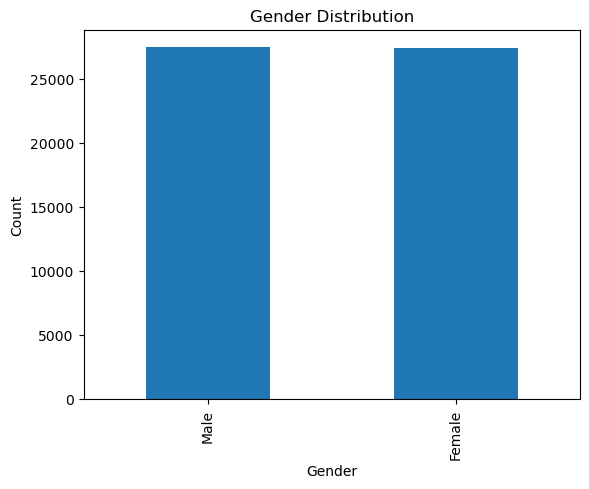

In [18]:
df["Gender"].value_counts().plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

### 2. Medical Condition Distribution

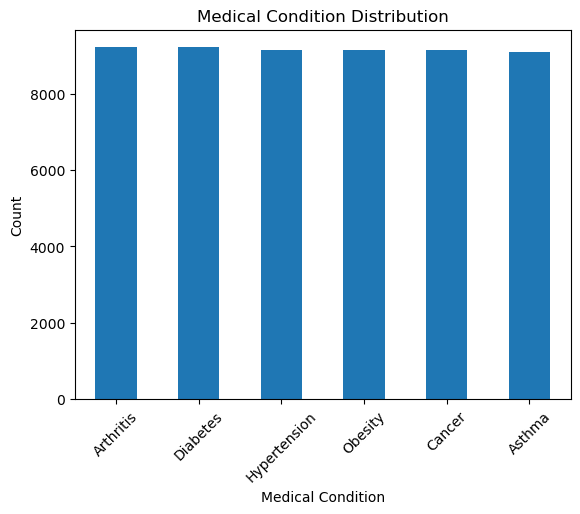

In [19]:
df["Medical Condition"].value_counts().plot(kind="bar")

plt.title("Medical Condition Distribution")
plt.xlabel("Medical Condition")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

### 3. Age Group Distribution

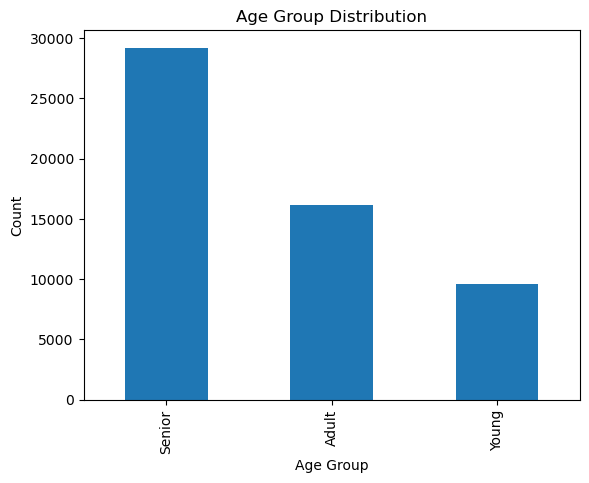

In [20]:
df["Age Group"].value_counts().plot(kind="bar")

plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Count")

plt.show()

### 4. Admission Type Distribution

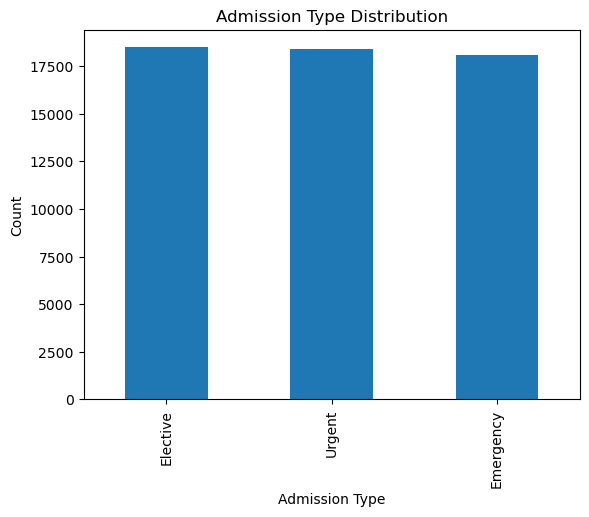

In [21]:
df["Admission Type"].value_counts().plot(kind="bar")

plt.title("Admission Type Distribution")
plt.xlabel("Admission Type")
plt.ylabel("Count")

plt.show()

### 5. Billing Amount Distribution

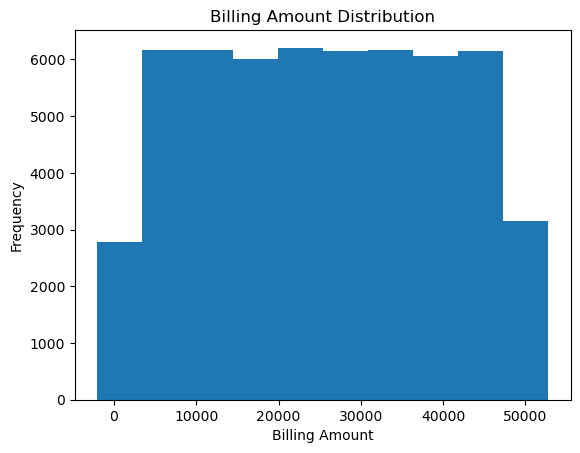

In [22]:
plt.hist(df["Billing Amount"])

plt.title("Billing Amount Distribution")
plt.xlabel("Billing Amount")
plt.ylabel("Frequency")

plt.show()

### 6. Correlation Heatmap

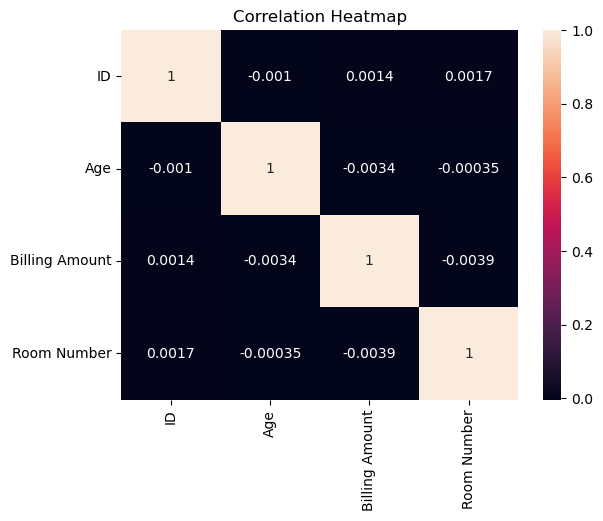

In [23]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.title("Correlation Heatmap")

plt.show()

### 7. Billing Amount Spread by Medical Condition Box plot

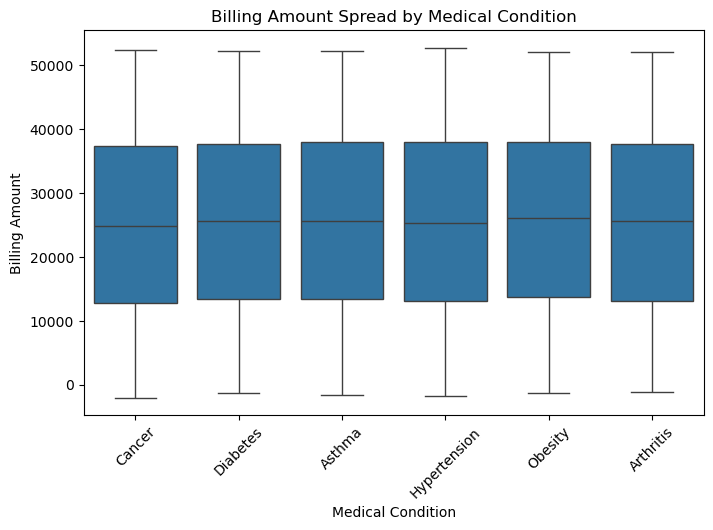

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Medical Condition", y="Billing Amount", data=df)

plt.title("Billing Amount Spread by Medical Condition")

plt.xticks(rotation=45)

plt.show()

## Step 9 — Insights


From the analysis of healthcare dataset, several important patterns were observed:

1. Gender Distribution  
The number of male and female patients is almost equal, indicating balanced representation in the dataset. This suggests that healthcare services are utilized similarly by both genders.

2. Medical Condition Frequency  
Medical conditions such as Arthritis, Diabetes, Hypertension, Obesity, Cancer, and Asthma appear with similar frequency. This shows the dataset includes a wide variety of diseases without bias toward a single condition.

3. Age Group Pattern  
The Senior age group has the highest number of hospital admissions, followed by Adults and Young individuals. This indicates that older people tend to require more medical attention.

4. Admission Type Analysis  
Elective, Urgent, and Emergency admission types are almost evenly distributed, showing hospitals handle different levels of medical urgency consistently.

5. Billing Amount Distribution  
Billing amounts vary widely from low to high values, indicating that treatment costs differ based on patient condition and hospital services.

6. Relationship between Variables  
Correlation analysis shows very weak relationships between Age, Billing Amount, and Room Number, meaning these variables do not strongly influence each other directly.

7. Billing Spread by Medical Condition  
The boxplot shows that billing amount distribution is similar across different medical conditions, with moderate variation in treatment cost range.

## Step 10 — Conclusion

- The Health Data Trend Report project analyzed healthcare dataset containing 55,500 patient records to identify patterns and trends in patient demographics, medical conditions, admission types, and billing amounts.

- The analysis showed balanced distribution of male and female patients and similar frequency of medical conditions such as Diabetes, Cancer, Asthma, Arthritis, Hypertension, and Obesity. The Senior age group had the highest number of hospital admissions, suggesting that older individuals require more medical care.

- Billing amount analysis indicated variation in treatment costs, but no strong relationship was found between age and billing amount. The admission types (Elective, Urgent, Emergency) were evenly distributed, showing consistent hospital service patterns.

- Overall, exploratory data analysis helped in understanding healthcare trends and patterns. Such insights can support healthcare providers in planning resources, improving services, and managing treatment costs efficiently.